In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install torch --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
print("All libraries loaded")

All libraries loaded


In [ ]:
np.random.seed(42)
n=1000

age=np.random.randint(20,80,n)
bmi        = np.round(np.random.normal(27.5, 5.5, n), 1)
glucose    = np.random.randint(70, 200, n)
blood_pres = np.random.randint(60, 130, n)
insulin    = np.random.randint(0, 300, n)

diabetes=((glucose>140)|(bmi>30)).astype(int)

print(f"Array shapes: age={age.shape}, diabetes={diabetes.shape}")
print(f"Positive cases: {diabetes.sum()} / {n}")



Array shapes: age=(1000,), diabetes=(1000,)
Positive cases: 657 / 1000


In [ ]:
df = pd.DataFrame({
    'age': age,
    'bmi': bmi,
    'glucose': glucose,
    'blood_pressure': blood_pres,
    'insulin': insulin,
    'diabetes': diabetes
})

mask = np.random.choice([True, False], size=n, p=[0.08, 0.92])
df.loc[mask, 'insulin'] = np.nan

df.to_csv('patients.csv', index=False)
print(df.head())
print(f"\nMissing values:\n{df.isnull().sum()}")

   age   bmi  glucose  blood_pressure  insulin  diabetes
0   58  27.5      173             125    209.0         1
1   71  25.2      142              93    295.0         1
2   48  34.5      118              67     96.0         1
3   34  27.0      105              72    207.0         0
4   62  32.7      195              67    136.0         1

Missing values:
age                0
bmi                0
glucose            0
blood_pressure     0
insulin           79
diabetes           0
dtype: int64


In [ ]:
df = pd.read_csv('patients.csv')

df['insulin'].fillna(df['insulin'].median(), inplace=True)

df = df[(df['bmi'] > 10) & (df['bmi'] < 60)]

df['age'] = df['age'].astype(int)
df['diabetes'] = df['diabetes'].astype(int)

print("After cleaning:")
print(df.info())
print(f"\nNull values remaining: {df.isnull().sum().sum()}")

After cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             1000 non-null   int64  
 1   bmi             1000 non-null   float64
 2   glucose         1000 non-null   int64  
 3   blood_pressure  1000 non-null   int64  
 4   insulin         1000 non-null   float64
 5   diabetes        1000 non-null   int64  
dtypes: float64(2), int64(4)
memory usage: 47.0 KB
None

Null values remaining: 0


/tmp/ipykernel_4463/808835000.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['insulin'].fillna(df['insulin'].median(), inplace=True)


In [ ]:
def bmi_category(bmi):
    if bmi < 18.5: return 'Underweight'
    elif bmi < 25:  return 'Normal'
    elif bmi < 30:  return 'Overweight'
    else:           return 'Obese'
df['bmi_cat'] = df['bmi'].apply(bmi_category)
df['age_group'] = pd.cut(df['age'], bins=[20,35,50,65,80],
                          labels=['Young','Middle','Senior','Elderly'])


risk_by_age = df.groupby('age_group', observed=True)['diabetes'].mean().reset_index()
risk_by_age.columns = ['age_group', 'diabetes_rate']
risk_by_age['diabetes_rate'] = (risk_by_age['diabetes_rate'] * 100).round(1)

df = df.merge(risk_by_age, on='age_group', how='left')
print(df[['age', 'age_group', 'bmi_cat', 'diabetes_rate']].head(10))
print("\nRisk by age group:")
print(risk_by_age)

   age age_group      bmi_cat  diabetes_rate
0   58    Senior   Overweight           64.8
1   71   Elderly   Overweight           66.7
2   48    Middle        Obese           67.2
3   34     Young   Overweight           63.0
4   62    Senior        Obese           64.8
5   27     Young       Normal           63.0
6   40    Middle   Overweight           67.2
7   58    Senior        Obese           64.8
8   77   Elderly  Underweight           66.7
9   38    Middle       Normal           67.2

Risk by age group:
  age_group  diabetes_rate
0     Young           63.0
1    Middle           67.2
2    Senior           64.8
3   Elderly           66.7


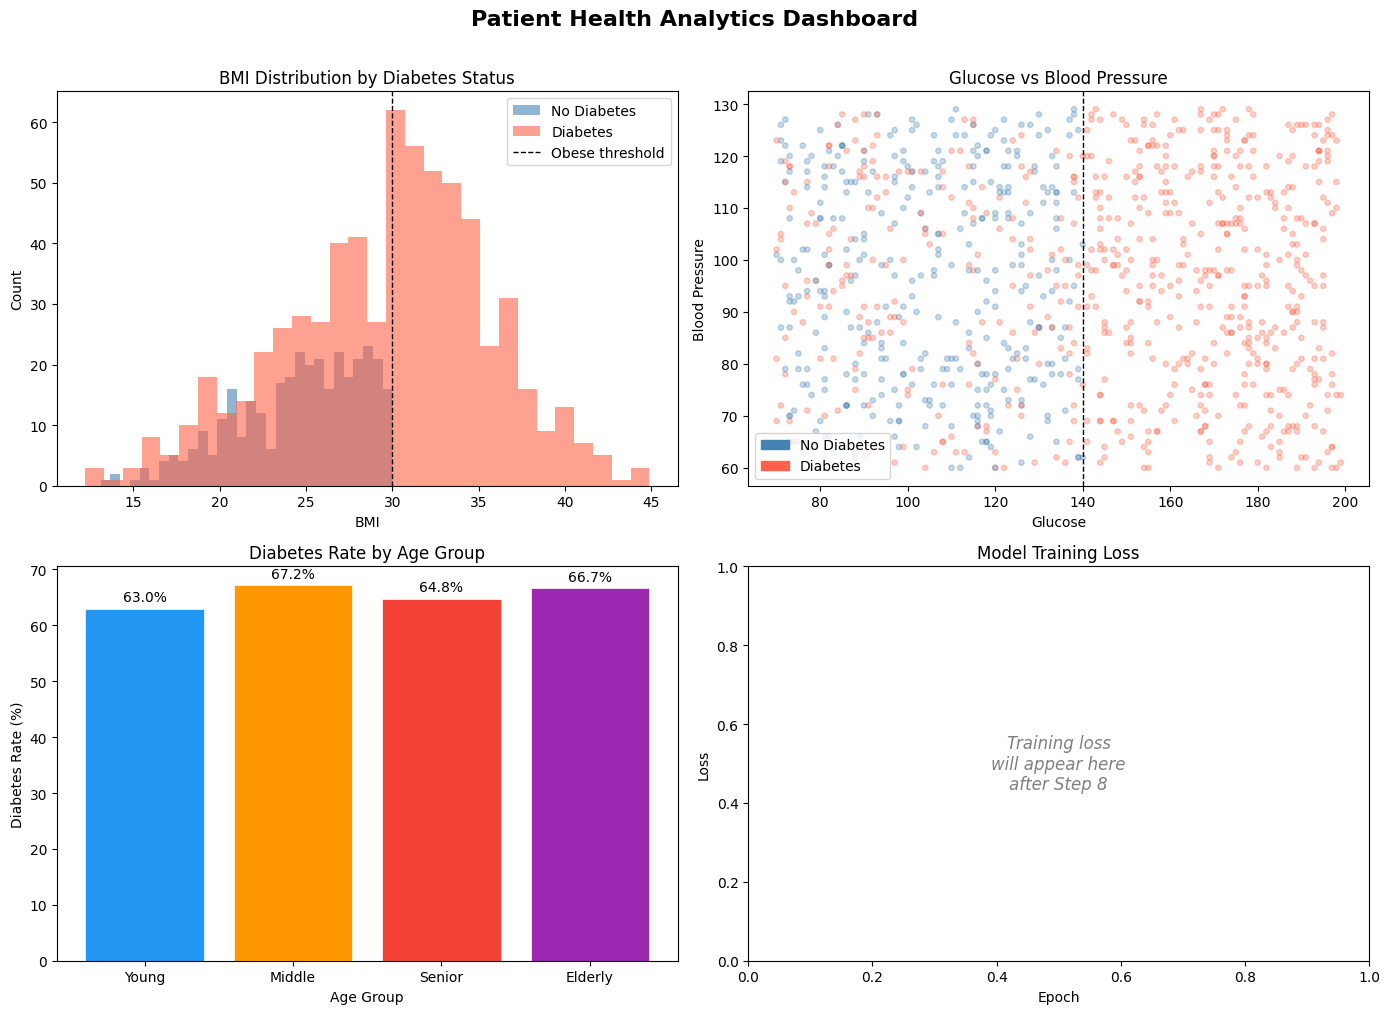

Dashboard saved as dashboard.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Patient Health Analytics Dashboard', fontsize=16, fontweight='bold', y=1.01)

ax = axes[0, 0]
ax.hist(df[df['diabetes']==0]['bmi'], bins=30, alpha=0.6, color='steelblue', label='No Diabetes')
ax.hist(df[df['diabetes']==1]['bmi'], bins=30, alpha=0.6, color='tomato',    label='Diabetes')
ax.axvline(30, color='black', linestyle='--', linewidth=1, label='Obese threshold')
ax.set_title('BMI Distribution by Diabetes Status')
ax.set_xlabel('BMI'); ax.set_ylabel('Count'); ax.legend()

ax = axes[0, 1]
colors = ['steelblue' if d == 0 else 'tomato' for d in df['diabetes']]
ax.scatter(df['glucose'], df['blood_pressure'], c=colors, alpha=0.3, s=15)
ax.axvline(140, color='black', linestyle='--', linewidth=1, label='High glucose')
ax.set_title('Glucose vs Blood Pressure')
ax.set_xlabel('Glucose'); ax.set_ylabel('Blood Pressure')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue', label='No Diabetes'),
                   Patch(color='tomato', label='Diabetes')])

ax = axes[1, 0]
colors_bar = ['#2196F3','#FF9800','#F44336','#9C27B0']
bars = ax.bar(risk_by_age['age_group'], risk_by_age['diabetes_rate'],
              color=colors_bar, edgecolor='white', linewidth=0.5)
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_title('Diabetes Rate by Age Group')
ax.set_xlabel('Age Group'); ax.set_ylabel('Diabetes Rate (%)')

ax = axes[1, 1]
ax.text(0.5, 0.5, 'Training loss\nwill appear here\nafter Step 8',
        ha='center', va='center', transform=ax.transAxes,
        fontsize=12, color='gray', style='italic')
ax.set_title('Model Training Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')

plt.tight_layout()
plt.savefig('dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved as dashboard.png")

In [ ]:
# Cell 7: NumPy arrays → PyTorch Tensors
features = ['age', 'bmi', 'glucose', 'blood_pressure', 'insulin']
X = df[features].values.astype(np.float32)
y = df['diabetes'].values.astype(np.float32)

# Normalize features using NumPy (vectorized — no loops!)
X_mean = X.mean(axis=0)
X_std  = X.std(axis=0)
X_norm = (X - X_mean) / X_std      # Broadcasting! shape (1000,5) - (5,) works automatically

# Train/test split manually
split = int(0.8 * len(X_norm))
X_train, X_test = X_norm[:split], X_norm[split:]
y_train, y_test = y[:split],      y[split:]

# Convert to Tensors
X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train).unsqueeze(1)   # shape: (800, 1)
X_test_t  = torch.tensor(X_test)
y_test_t  = torch.tensor(y_test).unsqueeze(1)

print(f"X_train tensor: {X_train_t.shape} | dtype: {X_train_t.dtype}")
print(f"y_train tensor: {y_train_t.shape}")
print(f"\nSample normalized row: {X_train_t[0]}")

X_train tensor: torch.Size([800, 5]) | dtype: torch.float32
y_train tensor: torch.Size([800, 1])

Sample normalized row: tensor([ 0.4492, -0.0730,  1.0079,  1.4525,  0.7137])


Epoch  20 | Loss: 0.6405
Epoch  40 | Loss: 0.6164
Epoch  60 | Loss: 0.5805
Epoch  80 | Loss: 0.5323
Epoch 100 | Loss: 0.4762

Training complete!


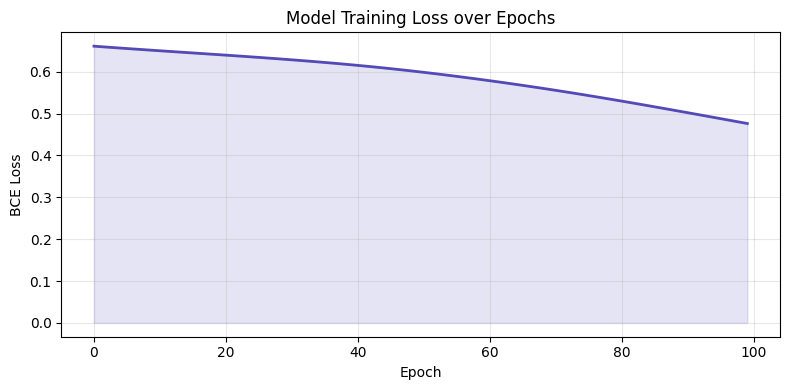

In [ ]:
# Cell 8: Define model, train, and plot loss
class DiabetesNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, 16),    # 5 features → 16 neurons
            nn.ReLU(),
            nn.Linear(16, 8),    # 16 → 8 neurons
            nn.ReLU(),
            nn.Linear(8, 1),     # 8 → 1 output
            nn.Sigmoid()         # Output: probability between 0 and 1
        )
    def forward(self, x):
        return self.net(x)

model    = DiabetesNet()
loss_fn  = nn.BCELoss()                         # Binary Cross Entropy for 0/1 prediction
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# --- Training loop ---
epochs = 100
loss_history = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()          # Clear old gradients
    preds = model(X_train_t)       # Forward pass
    loss  = loss_fn(preds, y_train_t)
    loss.backward()                # Backpropagation
    optimizer.step()               # Update weights
    loss_history.append(loss.item())
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d} | Loss: {loss.item():.4f}")

print("\nTraining complete!")

# --- Plot training loss (fills the 4th chart slot) ---
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='#534AB7', linewidth=2)
plt.fill_between(range(epochs), loss_history, alpha=0.15, color='#534AB7')
plt.title('Model Training Loss over Epochs')
plt.xlabel('Epoch'); plt.ylabel('BCE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 9: Test accuracy + predict a new patient
model.eval()
with torch.no_grad():
    test_preds = model(X_test_t)
    test_preds_binary = (test_preds > 0.5).float()
    accuracy = (test_preds_binary == y_test_t).float().mean()
    print(f"Test Accuracy: {accuracy.item()*100:.1f}%")

# --- Predict a new patient ---
# Age=55, BMI=33, Glucose=160, BP=90, Insulin=100
new_patient = np.array([[55, 33.0, 160, 90, 100]], dtype=np.float32)
new_norm    = (new_patient - X_mean) / X_std           # Same normalization!
new_tensor  = torch.tensor(new_norm)

with torch.no_grad():
    prob = model(new_tensor).item()

print(f"\nNew patient risk probability: {prob:.1%}")
print(f"Prediction: {'⚠️  HIGH RISK — refer to specialist' if prob > 0.5 else '✅ Low risk'}")

Test Accuracy: 82.5%

New patient risk probability: 78.4%
Prediction: ⚠️  HIGH RISK — refer to specialist


In [ ]:
import os


os.remove('/content/drive/MyDrive/diabetes_model.pth')
print("Deleted corrupted file")


torch.save({
    'model_state': model.state_dict(),
    'X_mean': X_mean,
    'X_std': X_std
}, '/content/drive/MyDrive/diabetes_model.pth')


test_load = torch.load('/content/drive/MyDrive/diabetes_model.pth', weights_only=False)
print("Keys found:", list(test_load.keys()))
print("All good!")

Deleted corrupted file
Keys found: ['model_state', 'X_mean', 'X_std']
All good!
